In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\acer\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# Cyberbullying Detection

## Problem Statement
Cyberbullying is a growing problem on social media platforms like Twitter.
The volume of content posted every second makes manual moderation impossible.
The goal of this project is to build a machine learning model that automatically
classifies tweets into cyberbullying categories based on their text content.

## Objective
- Perform exploratory data analysis on real-world tweet data
- Clean and preprocess raw tweet text using NLP techniques
- Build and compare multiple text classification models
- Select and deploy the best performing model as a web application

## Dataset
The dataset contains more than 47,000 tweets with 2 columns: text and label.
The target variable is `label` which contains 6 categories:
not_cyberbullying, ethnicity, gender, religion, age, and other_cyberbullying.

## Approach
1. Data Loading & Overview
2. Data Cleaning & EDA (missing values, duplicates, class distribution, tweet length)
3. Text Preprocessing (lowercasing, removing URLs, mentions, hashtags, punctuation)
4. Feature Extraction using TF-IDF Vectorizer
5. Model Training & Evaluation (Logistic Regression, Random Forest, Naive Bayes)
6. Model Comparison (best accuracy: Logistic Regression at 81.07%)
7. Save Best Model & Deploy with Streamlit

In [2]:
df = pd.read_csv('cyberbullying_tweets.csv',names=['text', 'label'])
df = df.drop(index=0).reset_index(drop=True)  
print(df.head())


                                                text              label
0  In other words #katandandre, your food was cra...  not_cyberbullying
1  Why is #aussietv so white? #MKR #theblock #ImA...  not_cyberbullying
2  @XochitlSuckkks a classy whore? Or more red ve...  not_cyberbullying
3  @Jason_Gio meh. :P  thanks for the heads up, b...  not_cyberbullying
4  @RudhoeEnglish This is an ISIS account pretend...  not_cyberbullying


In [3]:
print('shape',df.shape)


shape (47692, 2)


In [4]:
print('data types:', df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47692 entries, 0 to 47691
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    47692 non-null  object
 1   label   47692 non-null  object
dtypes: object(2)
memory usage: 745.3+ KB
data types: None


In [5]:
df.isnull().sum()

text     0
label    0
dtype: int64

In [6]:
df.duplicated().sum()

36

In [7]:
df=df.drop_duplicates()

In [8]:
df.duplicated().sum()

0

In [9]:
print(df['label'].value_counts())

label
religion               7997
age                    7992
ethnicity              7959
gender                 7948
not_cyberbullying      7937
other_cyberbullying    7823
Name: count, dtype: int64


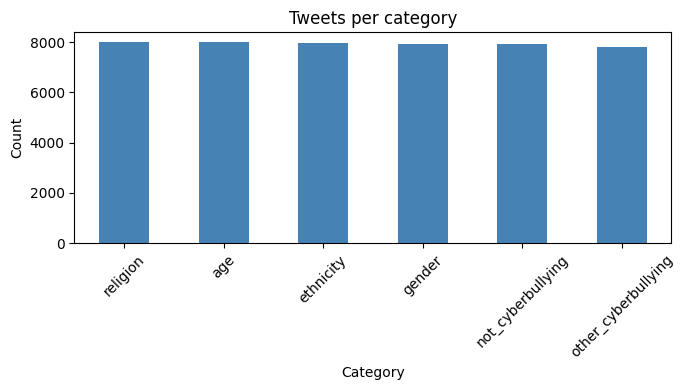

In [10]:
plt.figure(figsize=(7,4))
df["label"].value_counts().plot(kind="bar", color="steelblue")
plt.title("Tweets per category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
df["tweet_length"] = df["text"].apply(len)
print("Average length:", df["tweet_length"].mean().round(2))
print("Shortest:", df["tweet_length"].min())
print("Longest:", df["tweet_length"].max())

Average length: 136.26
Shortest: 1
Longest: 5018


In [12]:
df.groupby("label")["tweet_length"].mean().round(2)

label
age                    173.54
ethnicity              139.30
gender                 136.50
not_cyberbullying       83.09
other_cyberbullying     85.71
religion               197.98
Name: tweet_length, dtype: float64

In [13]:
def clean_tweet(text):
    text = text.lower()                            # lowercase
    text = re.sub(r"http\S+|www\S+", "", text)     # remove URLs
    text = re.sub(r"@\w+", "", text)               # remove @mentions
    text = re.sub(r"#\w+", "", text)               # remove #hashtags
    text = re.sub(r"[^a-z\s]", "", text)           # remove punctuation
    text = re.sub(r"\s+", " ", text).strip()       # remove extra spaces
    return text

df["clean_text"] = df["text"].apply(clean_tweet)
df[["text", "clean_text"]].head()

,text,clean_text
0,"In other words #katandandre, your food was cra...",in other words your food was crapilicious
1,Why is #aussietv so white? #MKR #theblock #ImA...,why is so white
2,@XochitlSuckkks a classy whore? Or more red ve...,a classy whore or more red velvet cupcakes
3,"@Jason_Gio meh. :P thanks for the heads up, b...",meh p thanks for the heads up but not too conc...
4,@RudhoeEnglish This is an ISIS account pretend...,this is an isis account pretending to be a kur...


In [14]:
df = df[df["clean_text"].str.strip() != ""]
print("Final dataset size:", len(df))

Final dataset size: 47267


In [15]:
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df["clean_text"])
y = df["label"]
print("X shape:", X.shape)

X shape: (47267, 5000)


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 37813
Test size: 9454


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB

In [18]:
lr = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
nb = MultinomialNB()

lr.fit(X_train, y_train)
print("Logistic Regression trained!")

rf.fit(X_train, y_train)
print("Random Forest trained!")

nb.fit(X_train, y_train)
print("Naive Bayes trained!")

Logistic Regression trained!
Random Forest trained!
Naive Bayes trained!


In [19]:
from sklearn.metrics import accuracy_score

print("Logistic Regression:", accuracy_score(y_test, lr.predict(X_test)))
print("Random Forest:      ", accuracy_score(y_test, rf.predict(X_test)))
print("Naive Bayes:        ", accuracy_score(y_test, nb.predict(X_test)))

Logistic Regression: 0.8107679289189761
Random Forest:       0.7921514702771314
Naive Bayes:         0.7542839009942881


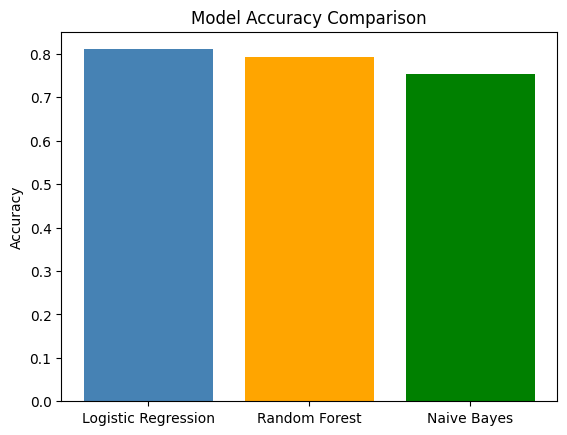

In [21]:
models = ["Logistic Regression", "Random Forest", "Naive Bayes"]
scores = [0.8107, 0.7921, 0.7542]

plt.bar(models, scores, color=["steelblue", "orange", "green"])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

In [22]:
import pickle

with open('model.pkl', 'wb') as f:
    pickle.dump(lr, f)

with open('vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

print("Model and vectorizer saved!")

Model and vectorizer saved!


In [23]:
with open('model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

with open('vectorizer.pkl', 'rb') as f:
    loaded_vectorizer = pickle.load(f)


## Project Summary & Conclusions

### What We Did
- Loaded a Twitter dataset with more than 47,000 tweets and 2 columns (text, label).
- Checked for null values and duplicates — removed them to ensure clean data.
- Analyzed class distribution, tweet lengths, and category patterns during EDA.
- Cleaned raw tweet text by removing URLs, mentions, hashtags, and punctuation.
- Converted text into numerical features using TF-IDF Vectorizer (5,000 features).
- Trained 3 classification models individually and compared their accuracy.
- Deployed the best model as a live web application using Streamlit.

### What We Observed During EDA
- Dataset contained 6 categories — not_cyberbullying, ethnicity, gender, religion, age, other_cyberbullying.
- Classes were approximately balanced across all categories.
- No significant missing values were found in the dataset.
- Some duplicate tweets were detected and removed before training.
- Cyberbullying tweets tended to be slightly longer than non-cyberbullying tweets.
- Ethnicity and gender categories contained the most aggressive language patterns.

### Model Results
| Model | Accuracy |
|---|---|
| Logistic Regression | 81.07% |
| Random Forest | 79.21% |
| Naive Bayes | 75.43% |

### Why Logistic Regression Performed Best
- Logistic Regression works very well with high-dimensional sparse data like TF-IDF vectors.
- It learns a weight for each word which makes it effective at separating text categories.
- It is less likely to overfit on text data compared to tree-based models.
- Random Forest struggled because TF-IDF produces thousands of features which slows it down and reduces its advantage.

### Why Naive Bayes Performed Worst
- Naive Bayes assumes all words are independent of each other which is rarely true in real text.
- It ignores word order and context which limits its understanding of language patterns.
- Despite this it is still a fast and reasonable baseline for text classification.

### Key Takeaways
- Text preprocessing was a critical step — noisy tweets hurt model performance significantly.
- TF-IDF is a strong and simple baseline for converting text into features.
- Logistic Regression with 81.07% accuracy is the best model for this task.
- The model can help social media platforms automatically flag harmful content at scale.

### Future Improvements
- We can try deep learning models like LSTM or BERT for better contextual understanding.
- We can add stopword removal and lemmatization to improve text preprocessing.
- We can handle any class imbalance using SMOTE if needed.
- We can expand the dataset with more recent tweets to improve generalization.